# Lab 5: The Defective Filament
## Variable-Coefficient PDEs: FDM vs. PINNs

In this lab, you will model the voltage, electric field, and heat generation across a 1D tungsten filament that has a manufacturing defect. You will solve the charge continuity equation using both a traditional Staggered-Grid Finite Difference Method (FDM) and a Physics-Informed Neural Network (PINN).

> **Accessibility Note for Screen Readers:** This notebook uses MathJax to render LaTeX equations. If your screen reader has difficulty parsing the math blocks, explicit plain-text descriptions of the governing physics are provided in the notes below each mathematical section. Additionally, whenever a code cell generates a visual plot, you are encouraged to print the resulting arrays (e.g., `print(V_fdm)`) to read the numerical output directly.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

---
### Part 1: Object-Oriented Physics Setup
First, we construct the classes needed to represent our materials and the filament itself, exactly as we discussed in lecture.

The physical constants used are the elementary charge ($e = 1.602 \times 10^{-19}$ Coulombs) and the electron mass ($m_e = 9.109 \times 10^{-31}$ kilograms).

In [20]:
class Material:
    """Base blueprint for a conductive material."""
    e = 1.602e-19
    m_e = 9.109e-31

    def __init__(self, n, tau, name="Generic"):
        self.name = name
        self.n = n
        self.tau = tau

    def get_conductivity(self):
        """Calculates Drude conductivity sigma = n * e^2 * tau / m_e"""
        return (self.n * self.e**2 * self.tau) / self.m_e

class Tungsten(Material):
    def __init__(self):
        super().__init__(n=6.3e28, tau=1.9e-14, name="Tungsten")

class Filament:
    """A 1D filament with a manufacturing defect."""
    def __init__(self, material, length=0.1, defect_center=0.05, defect_width=0.005):
        self.material = material
        self.L = length
        self.x_c = defect_center
        self.w = defect_width

    def sigma(self, x):
        """Conductivity drops by 50% at the Gaussian defect."""
        base_sig = self.material.get_conductivity()
        # Handle both numpy arrays and PyTorch tensors gracefully
        if isinstance(x, torch.Tensor):
            defect = 0.5 * torch.exp(-((x - self.x_c)**2) / (2 * self.w**2))
        else:
            defect = 0.5 * np.exp(-((x - self.x_c)**2) / (2 * self.w**2))
        return base_sig * (1.0 - defect)

---
### Part 2: The Staggered-Grid FDM Solver
Complete the `solve_fdm` function by populating the interior points of the tridiagonal matrix `A`.

The governing equation is a variable-coefficient Poisson equation. To solve this without calculus errors, we evaluate the voltage exactly on the grid nodes, but we evaluate the conductivity exactly halfway between the nodes.

> **Screen Reader Note:** The following code cell will generate a line graph plotting Voltage on the Y-axis versus Position on the X-axis. The expected result is a line that slopes downward from 120 Volts to 0 Volts, with a noticeably steeper drop exactly in the middle of the wire where the defect is located.

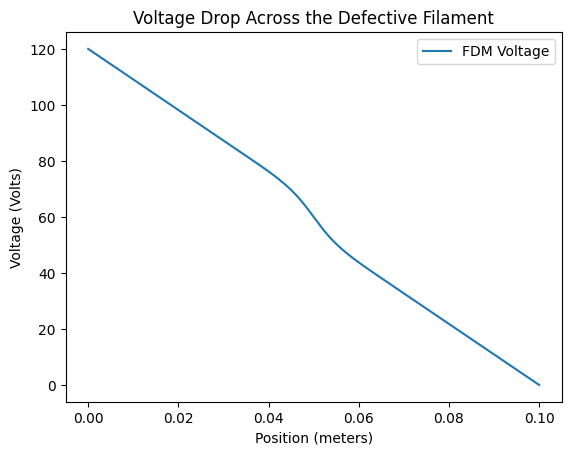

In [21]:
def solve_fdm(filament, N=100):
    x = np.linspace(0, filament.L, N)
    dx = x[1] - x[0]

    # Evaluate sigma at the N-1 half steps
    # sig_half[i] represents the conductivity exactly halfway between node i and node i+1
    x_half = x[:-1] + dx/2
    sig_half = np.array([filament.sigma(xi) for xi in x_half])

    A = np.zeros((N, N))
    b = np.zeros(N)

    # Boundary Conditions: Voltage at x=0 is 120V. Voltage at x=L is 0V.
    A[0, 0] = 1.0; b[0] = 120.0
    A[-1, -1] = 1.0; b[-1] = 0.0

    # TODO: Fill in the interior rows of matrix A using the staggered grid formula
    # Hint: Loop over range(1, N-1). Use sig_half[i-1] and sig_half[i].
    for i in range(1, N-1):
      A[i, i-1] = sig_half[i-1]
      A[i, i] = -sig_half[i-1] - sig_half[i]
      A[i, i+1] = sig_half[i]

    V = np.linalg.solve(A, b)
    return x, V

# Test your FDM solver
bulb = Filament(Tungsten())
x_fdm, V_fdm = solve_fdm(bulb, N=150)

plt.plot(x_fdm, V_fdm, label="FDM Voltage")
plt.title("Voltage Drop Across the Defective Filament")
plt.xlabel("Position (meters)")
plt.ylabel("Voltage (Volts)")
plt.legend()
plt.show()

# Uncomment the line below to read the raw numerical output array
# print(V_fdm)

---
### Part 3: The PINN Solver
Here we define the neural network and the custom loss function for the variable-coefficient PDE. We do not need a staggered grid here, because PyTorch evaluates the derivatives continuously.

**The Physics to translate to code:**
1. The Electric Field is the negative derivative of Voltage with respect to position.
2. Current Density ($J$) is Conductivity ($\sigma$) multiplied by the Electric Field.
3. The PDE residual is the derivative of $J$ with respect to position, which must equal zero.

In [22]:
class PDE_Net(nn.Module):
    def __init__(self):
        super(PDE_Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

def compute_pde_residual(model, x, filament):
    x.requires_grad_(True)

    # 1. Get Voltage from neural net
    V = model(x)

    # 2. First derivative (dV/dx)
    V_x = torch.autograd.grad(
        V, x, grad_outputs=torch.ones_like(V),
        create_graph=True
    )[0]

    # 3. Get sigma(x) as a tensor
    sig = filament.sigma(x)

    # 4. Current Density (Ohm's Law)
    J = sig * V_x

    # 5. TODO: Calculate divergence of J (dJ/dx) using torch.autograd.grad
    # Note: Differentiate J here, not V_x!
    J_x = torch.autograd.grad(
        outputs = J,
        inputs = x,
        grad_outputs = torch.ones_like(J),
        create_graph = True,
        retain_graph = True
    )[0]


    return J_x
    pass

### Part 3B: The PINN Training Loop
Complete the missing pieces of the training loop below. Pay close attention to your tensor shapes.

> **Screen Reader Note:** The following code cell will generate a line graph plotting the training loss on a logarithmic Y-axis versus the training epoch on the X-axis. A successful run will show the loss curve rapidly decaying downward toward zero.

Epoch 0 | Loss: 52001618526208.0000
Epoch 500 | Loss: 2511912960.0000
Epoch 1000 | Loss: 2077450112.0000
Epoch 1500 | Loss: 1901391104.0000
Epoch 2000 | Loss: 2079250176.0000
Epoch 2500 | Loss: 1665421824.0000


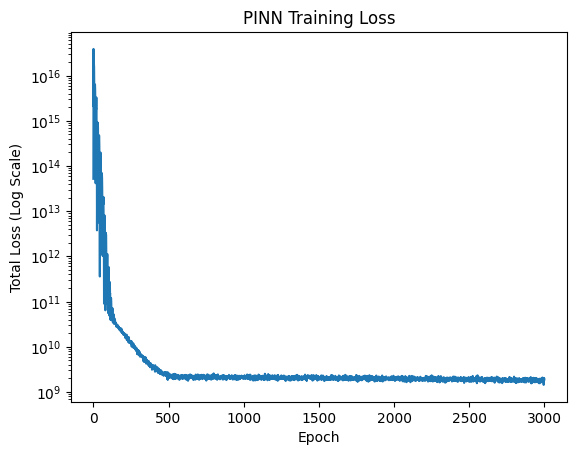

In [23]:
# --- PINN Training Setup ---
pinn_model = PDE_Net()
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=0.01)
bulb = Filament(Tungsten())
epochs = 3000

# Generate boundary points (Tensors require shape N x 1)
x_left = torch.tensor([[0.0]])
x_right = torch.tensor([[bulb.L]])

loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    # 1. Domain Loss (The Physics)
    # TODO: Generate 200 random collocation points between 0 and bulb.L
    x_domain = torch.tensor([np.random.uniform(low = 0, high = bulb.L, size = (200,1))], dtype = torch.float)

    # TODO: Compute the PDE residual using the function you wrote above
    residual = compute_pde_residual(pinn_model, x_domain, bulb)

    # TODO: Calculate the Mean Squared Error of the residual
    loss_pde = torch.mean(residual**2)


    # 2. Boundary Loss (The Circuit)
    # TODO: Predict voltage at x_left. Calculate Mean Squared Error against the target (120 Volts)
    loss_bc_left = torch.mean((pinn_model(x_left) - torch.tensor([[120.0]]))**2)

    # TODO: Predict voltage at x_right. Calculate Mean Squared Error against the target (0 Volts)
    loss_bc_right = torch.mean((pinn_model(x_right))**2)


    # 3. Optimize
    # TODO: Combine losses, call backward(), and step the optimizer
    loss_total = loss_pde + loss_bc_left + loss_bc_right
    loss_total.backward()
    optimizer.step()

    # (Uncomment the line below when loss_total is defined)
    loss_history.append(loss_total.item())

    if epoch % 500 == 0:
        # (Uncomment the print statement below when loss_total is defined)
        print(f"Epoch {epoch} | Loss: {loss_total.item():.4f}")
        pass

# Plot the training loss to verify convergence
plt.plot(loss_history)
plt.yscale('log')
plt.title("PINN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (Log Scale)")
plt.show()

---
### Part 4: Physics Payoff
Calculate and plot the Electric Field $E(x)$ and the Joule Heating density $S(x)$ across the wire for your solutions.

Create a new Markdown cell below your plots to answer the three questions from Section 4 of the Lab Manual regarding the physical behavior of the defect and the comparison between the FDM and PINN methods.

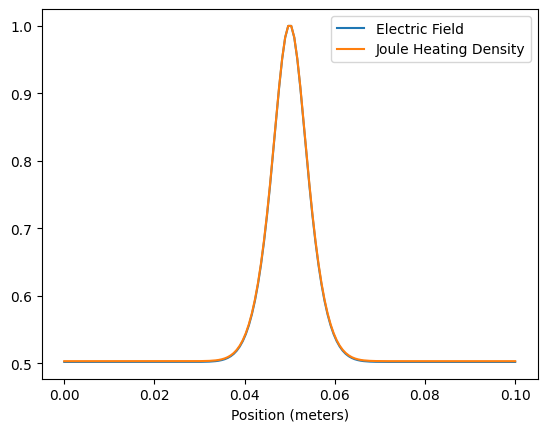

In [24]:
# Write your code to calculate and plot E(x) and S(x) here.
E = -np.gradient(V_fdm, x_fdm)
S = np.zeros(len(x_fdm))
for i in range(len(x_fdm)):
  sigma = bulb.sigma(x_fdm[i].item())
  S[i] = sigma*E[i]*E[i]

E_norm = E/np.max(E)
S_norm = S/np.max(S)
plt.plot(x_fdm, E_norm, label="Electric Field")
plt.plot(x_fdm, S_norm, label="Joule Heating Density")
plt.xlabel("Position (meters)")
plt.legend()
plt.show()